# Arabic Handwritten Word Recognition — CRNN + CTC
**Run all cells top-to-bottom. Do not skip any cell.**

### Architecture
- Word image (32×128 grayscale) → CNN feature extractor → BiLSTM → Dense (31 outputs: 30 chars + CTC blank)
- CTC loss trains end-to-end — no character segmentation needed at inference time
- Ground-truth label sequences derived automatically from your YOLO bounding-box annotations
- Evaluation metric: Character Error Rate (CER)


## Cell 1 — Install dependencies

In [1]:
import subprocess, sys
pkgs = ['tensorflow','opencv-python-headless','numpy','matplotlib','tqdm','scikit-learn']
for p in pkgs:
    subprocess.run([sys.executable,'-m','pip','install','-q',p], check=False)
print('All packages ready.')


All packages ready.


## Cell 2 — Imports and constants

In [2]:
import os, cv2, random, warnings
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

ROOT       = Path(r'F:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN')
MY_DATASET = ROOT / 'my_dataset'
assert MY_DATASET.exists(), f'Dataset not found: {MY_DATASET}'

CLASS_NAMES = [
    'ain','alef','beh','dad','dal','feh','ghain','hah','hamza','heh',
    'jeem','kaf','khah','lam','meem','noon','qaf','reh','sad','seen',
    'sheen','tah','teh','teh_marbota','thal','theh','waw','yeh','zah','zain'
]
NUM_CLASSES   = len(CLASS_NAMES)   # 30
BLANK_IDX     = NUM_CLASSES        # 30 — CTC blank token
IMG_H, IMG_W  = 32, 128
MAX_LABEL_LEN = 12   # updated automatically in Cell 3
BATCH_SIZE    = 8
EPOCHS        = 150
LR            = 1e-3

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f'GPU: {gpus[0].name}')
else:
    print('No GPU found — running on CPU (training will be slow)')
print(f'TensorFlow {tf.__version__}')


No GPU found — running on CPU (training will be slow)
TensorFlow 2.18.0


## Cell 3 — Load word dataset from YOLO annotations

In [3]:
def load_word_dataset(dataset_root, split='train'):
    """
    Read each word image and derive the character label sequence from
    the corresponding YOLO label file.
    Boxes are sorted right-to-left by x_center (Arabic reading order).
    Returns: list of (image_path, [class_id, ...]) tuples.
    """
    images_dir = Path(dataset_root) / split / 'images'
    labels_dir = Path(dataset_root) / split / 'labels'
    items = []
    for img_path in sorted(images_dir.iterdir()):
        if img_path.suffix.lower() not in ('.jpg','.jpeg','.png','.bmp'):
            continue
        lbl_path = labels_dir / (img_path.stem + '.txt')
        if not lbl_path.exists():
            continue
        boxes = []
        for line in lbl_path.read_text().splitlines():
            p = line.strip().split()
            if len(p) >= 5:
                boxes.append((int(p[0]), float(p[1])))  # (class_id, x_center)
        if not boxes:
            continue
        boxes.sort(key=lambda b: -b[1])   # right-to-left
        items.append((img_path, [b[0] for b in boxes]))
    return items


train_items = load_word_dataset(MY_DATASET, 'train')
val_items   = load_word_dataset(MY_DATASET, 'val')
print(f'Train word images : {len(train_items)}')
print(f'Val   word images : {len(val_items)}')

all_lens = [len(lbl) for _, lbl in train_items + val_items]
print(f'Label lengths — min:{min(all_lens)}  max:{max(all_lens)}  mean:{np.mean(all_lens):.1f}')
MAX_LABEL_LEN = max(all_lens)
print(f'MAX_LABEL_LEN set to {MAX_LABEL_LEN}')


Train word images : 469
Val   word images : 40
Label lengths — min:2  max:9  mean:4.0
MAX_LABEL_LEN set to 9


## Cell 4 — Preprocessing and augmentation

Preprocessed shape: (32, 128, 1)  dtype: float32


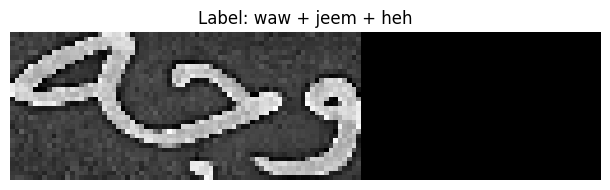

In [4]:
def preprocess_word_image(img_path, h=IMG_H, w=IMG_W):
    """
    Load → CLAHE → Otsu binarise → crop to ink → resize to (h,w,1).
    Returns float32 array, ink=1.0, background=0.0.
    """
    img = cv2.imread(str(img_path))
    if img is None: return None
    gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(4,4))
    gray  = clahe.apply(gray)
    _, bw = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
    coords = cv2.findNonZero(bw)
    if coords is None: return None
    x, y, cw, ch = cv2.boundingRect(coords)
    roi    = gray[y:y+ch, x:x+cw]
    scale  = h / max(ch, 1)
    nw     = min(int(cw * scale), w)
    rsz    = cv2.resize(roi, (nw, h), interpolation=cv2.INTER_LANCZOS4)
    canvas = np.full((h, w), 255, dtype='uint8')
    canvas[:, :nw] = rsz[:, :nw]
    out = 1.0 - canvas.astype('float32') / 255.0   # invert: ink=1 bg=0
    return out[..., np.newaxis]   # shape: (H, W, 1)


def augment_word(img):
    """
    Safe augmentations for Arabic handwriting.
    NEVER flips horizontally (would mirror/reverse Arabic letters).
    """
    x = img.copy().squeeze()   # (H, W)
    # Gaussian noise — simulates scan/photo noise
    if random.random() < 0.5:
        x += np.random.normal(0, 0.03, x.shape).astype('float32')
    # Brightness — different pens and lighting conditions
    if random.random() < 0.5:
        x *= random.uniform(0.75, 1.25)
    # Small rotation — tilted paper or phone angle
    if random.random() < 0.4:
        angle = random.uniform(-5, 5)
        M = cv2.getRotationMatrix2D((IMG_W/2, IMG_H/2), angle, 1.0)
        x = cv2.warpAffine(x, M, (IMG_W, IMG_H),
                           borderMode=cv2.BORDER_CONSTANT, borderValue=0.0)
    # Morphological dilation — thicker strokes (different writers)
    if random.random() < 0.3:
        k   = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))
        u8  = (np.clip(x,0,1)*255).astype('uint8')
        x   = cv2.dilate(u8, k).astype('float32') / 255.0
    return np.clip(x, 0, 1)[..., np.newaxis]


# Sanity check
arr = preprocess_word_image(train_items[0][0])
print(f'Preprocessed shape: {arr.shape}  dtype: {arr.dtype}')
plt.figure(figsize=(8, 2))
plt.imshow(arr.squeeze(), cmap='gray')
plt.title('Label: ' + ' + '.join(CLASS_NAMES[c] for c in train_items[0][1]))
plt.axis('off'); plt.tight_layout(); plt.show()


## Cell 5 — Data generator

In [5]:
class WordDataGenerator(keras.utils.Sequence):
    def __init__(self, items, batch_size=BATCH_SIZE, augment=False):
        self.items, self.batch_size, self.augment = items, batch_size, augment
        self.indices = list(range(len(items)))

    def __len__(self):
        return max(1, len(self.items) // self.batch_size)

    def on_epoch_end(self):
        random.shuffle(self.indices)

    def __getitem__(self, idx):
        batch = [self.items[i]
                 for i in self.indices[idx*self.batch_size:(idx+1)*self.batch_size]]
        imgs, lbls = [], []
        for path, seq in batch:
            img = preprocess_word_image(path)
            if img is None: continue
            if self.augment: img = augment_word(img)
            lbl  = list(seq[:MAX_LABEL_LEN])
            lbl += [BLANK_IDX] * (MAX_LABEL_LEN - len(lbl))
            imgs.append(img); lbls.append(lbl)
        if not imgs:
            return self.__getitem__((idx+1) % len(self))
        return ({'image': np.array(imgs, 'float32'),
                 'label': np.array(lbls, 'float32')},
                np.zeros(len(imgs)))


train_gen = WordDataGenerator(train_items, augment=True)
val_gen   = WordDataGenerator(val_items,   augment=False)
print(f'Train batches: {len(train_gen)}   Val batches: {len(val_gen)}')


Train batches: 58   Val batches: 5


## Cell 6 — CRNN + CTC model

In [6]:
class CTCLayer(layers.Layer):
    """Adds CTC loss to the model graph — used during training only."""
    def call(self, y_true, y_pred):
        B  = tf.cast(tf.shape(y_true)[0], 'int64')
        T  = tf.cast(tf.shape(y_pred)[1], 'int64')
        L  = tf.cast(tf.shape(y_true)[1], 'int64')
        il = T * tf.ones((B, 1), dtype='int64')
        ll = L * tf.ones((B, 1), dtype='int64')
        self.add_loss(keras.backend.ctc_batch_cost(y_true, y_pred, il, ll))
        return y_pred


def build_crnn_backbone():
    """Pure CRNN inference model (no CTC loss layer)."""
    inp = keras.Input(shape=(IMG_H, IMG_W, 1), name='image')

    def cnn_block(x, filters, pool):
        x = layers.Conv2D(filters, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        return layers.MaxPooling2D(pool)(x)

    x = cnn_block(inp,  32,  (2,2))    # → (16, 64, 32)
    x = cnn_block(x,    64,  (2,2))    # → ( 8, 32, 64)
    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = cnn_block(x,   128,  (2,1))    # → ( 4, 32,128)
    x = cnn_block(x,   256,  (2,1))    # → ( 2, 32,256)
    x = cnn_block(x,   256,  (2,1))    # → ( 1, 32,256)

    # (batch,1,W,256) → (batch,W,256)  — time axis = width
    x = layers.Reshape((IMG_W // 4, 256))(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Bidirectional(layers.LSTM(256, return_sequences=True, dropout=0.25))(x)
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout=0.25))(x)

    out = layers.Dense(NUM_CLASSES + 1, activation='softmax', name='output')(x)
    return keras.Model(inp, out, name='CRNN_backbone')


def build_training_model():
    img_inp  = keras.Input(shape=(IMG_H, IMG_W, 1), name='image')
    lbl_inp  = keras.Input(shape=(None,), name='label', dtype='float32')
    backbone = build_crnn_backbone()
    y_pred   = backbone(img_inp)
    output   = CTCLayer(name='ctc_loss')(lbl_inp, y_pred)
    model    = keras.Model(inputs=[img_inp, lbl_inp], outputs=output)
    model.compile(optimizer=keras.optimizers.Adam(LR))
    return model, backbone


train_model, crnn_model = build_training_model()
crnn_model.summary()
print(f'Parameters: {crnn_model.count_params():,}')


Model: "CRNN_backbone"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 32, 128, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 128, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 128, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 128, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 32, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 32, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 32, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 32, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 32, 128)     │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 32, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 8, 32, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 32, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 32, 256)     │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 4, 32, 256)     │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 4, 32, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 32, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 2, 32, 256)     │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 2, 32, 256)     │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 2,909,727 (11.10 MB)

 Trainable params: 2,907,999 (11.09 MB)

 Non-trainable params: 1,728 (6.75 KB)

Parameters: 2,909,727


## Cell 7 — Train

Epoch 1/150
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - loss: 179.9568
Epoch 1: val_loss improved from inf to 111.72508, saving model to F:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN\crnn_ctc_model.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 22s 226ms/step - loss: 179.1098 - val_loss: 111.7251 - learning_rate: 0.0010
Epoch 2/150
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 110.8883
Epoch 2: val_loss did not improve from 111.72508
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step - loss: 110.8944 - val_loss: 122.4094 - learning_rate: 0.0010
Epoch 3/150
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 109.7562
Epoch 3: val_loss did not improve from 111.72508
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - loss: 109.7475 - val_loss: 125.2152 - learning_rate: 0.0010
Epoch 4/150
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 107.6182
Epoch 4: val_loss did not improve from 111.72508
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - loss: 107.6311 - val_loss: 117.2555 - learning_rate: 0.0010
Epoch 5/15

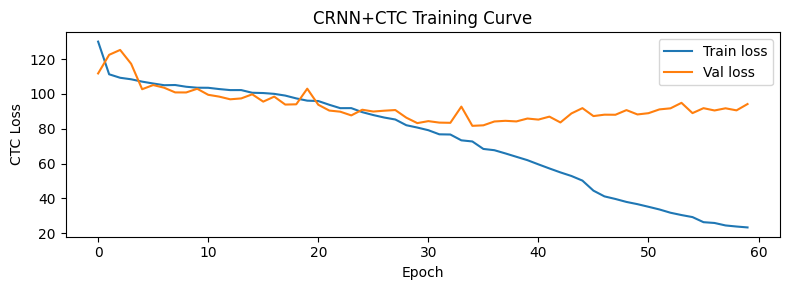

Best model saved to: F:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN\crnn_ctc_model.keras


In [7]:
SAVE_PATH = str(ROOT / 'crnn_ctc_model.keras')

callbacks = [
    keras.callbacks.ModelCheckpoint(
        SAVE_PATH, monitor='val_loss', save_best_only=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1),
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=25,
        restore_best_weights=True, verbose=1),
]

history = train_model.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS, callbacks=callbacks, verbose=1
)

plt.figure(figsize=(8, 3))
plt.plot(history.history['loss'],     label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.xlabel('Epoch'); plt.ylabel('CTC Loss')
plt.title('CRNN+CTC Training Curve')
plt.legend(); plt.tight_layout(); plt.show()
print(f'Best model saved to: {SAVE_PATH}')


## Cell 8 — Evaluate (Character Error Rate)

In [8]:
def ctc_greedy_decode(pred_probs):
    """Collapse repeated labels and remove blank tokens."""
    raw = np.argmax(pred_probs, axis=-1)
    out, prev = [], None
    for idx in raw:
        if idx != prev:
            if idx != BLANK_IDX:
                out.append(int(idx))
        prev = idx
    return out


def edit_distance(ref, hyp):
    r, h = list(ref), list(hyp)
    dp = np.zeros((len(r)+1, len(h)+1), dtype=int)
    for i in range(len(r)+1): dp[i,0] = i
    for j in range(len(h)+1): dp[0,j] = j
    for i in range(1, len(r)+1):
        for j in range(1, len(h)+1):
            cost = 0 if r[i-1]==h[j-1] else 1
            dp[i,j] = min(dp[i-1,j]+1, dp[i,j-1]+1, dp[i-1,j-1]+cost)
    return dp[len(r), len(h)]


total_ed, total_chars = 0, 0
for img_path, true_seq in tqdm(val_items, desc='Evaluating'):
    img = preprocess_word_image(img_path)
    if img is None: continue
    preds    = crnn_model.predict(img[np.newaxis], verbose=0)[0]
    pred_seq = ctc_greedy_decode(preds)
    total_ed    += edit_distance(true_seq, pred_seq)
    total_chars += len(true_seq)

cer = total_ed / max(1, total_chars)
print(f'Character Error Rate : {cer:.4f}')
print(f'Character Accuracy   : {(1-cer)*100:.1f}%')

print('\n--- Sample predictions ---')
for img_path, true_seq in val_items[:5]:
    img  = preprocess_word_image(img_path)
    pred = ctc_greedy_decode(crnn_model.predict(img[np.newaxis], verbose=0)[0])
    print(f'  True : {[CLASS_NAMES[c] for c in true_seq]}')
    print(f'  Pred : {[CLASS_NAMES[c] for c in pred if c < NUM_CLASSES]}')
    print()


Evaluating: 100%|██████████| 40/40 [00:04<00:00,  9.90it/s]


Character Error Rate : 0.7466
Character Accuracy   : 25.3%

--- Sample predictions ---
  True : ['ain', 'yeh', 'noon']
  Pred : ['jeem', 'beh', 'lam']

  True : ['waw', 'alef', 'kaf', 'lam']
  Pred : ['jeem', 'alef', 'lam']

  True : ['jeem', 'zain', 'meem', 'teh_marbota']
  Pred : ['reh', 'yeh', 'teh_marbota']

  True : ['lam', 'waw', 'hah', 'teh_marbota']
  Pred : ['reh', 'yeh', 'teh_marbota']

  True : ['ain', 'tah', 'waw', 'reh']
  Pred : ['ain', 'qaf', 'reh']



## Cell 9 — Inference on any word image

Ground truth: ['ain', 'yeh', 'noon']


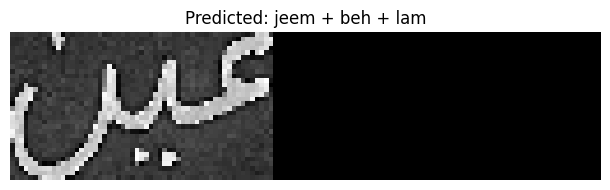

Characters: ['jeem', 'beh', 'lam']


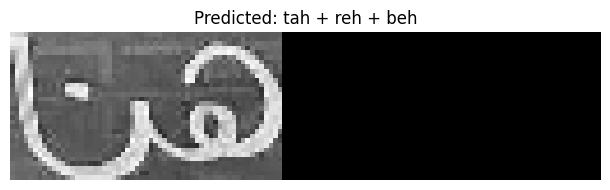

Characters: ['tah', 'reh', 'beh']


['tah', 'reh', 'beh']

In [9]:
def recognize_word_crnn(image_path):
    """
    Run CRNN+CTC inference on a single handwritten Arabic word image.
    Returns list of predicted character names.
    """
    img = preprocess_word_image(Path(image_path))
    if img is None:
        print('Cannot read image.'); return []
    preds   = crnn_model.predict(img[np.newaxis], verbose=0)[0]
    indices = ctc_greedy_decode(preds)
    names   = [CLASS_NAMES[i] for i in indices if i < NUM_CLASSES]
    plt.figure(figsize=(8, 2))
    plt.imshow(img.squeeze(), cmap='gray')
    title = 'Predicted: ' + ' + '.join(names) if names else 'No prediction'
    plt.title(title); plt.axis('off'); plt.tight_layout(); plt.show()
    print('Characters:', names)
    return names


# Test on first validation image
test_path, test_lbl = val_items[0]
print('Ground truth:', [CLASS_NAMES[c] for c in test_lbl])
recognize_word_crnn(test_path)

# Test on your own image (uncomment and change the path):
recognize_word_crnn(r'F:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN\word_test.png')
